# Pràctica 4 – Part 3: Avaluació Extrínseca (Spanish STS)
Max Villalba i Biel Sánchez  
_Processament del Llenguatge Humà - GIA_

Comparem tres aproximacions per mesurar la similitud entre frases:
1. **Baseline Cosinus** — mitjana simple i TF-IDF dels embeddings estàtics
2. **Model Seqüencial Siamès** — BiLSTM + Atenció sobre embeddings estàtics
3. **Model BERT Siamès** — BETO (BERT) + MLP de regressió

**Mètrica**: correlació de Pearson contra les puntuacions humanes del Spanish STS.

### 0. Instal·lació

Comencem instal·lant les llibreries necessàries per dur a terme aquesta part. Com a nota, la llibreria **datasets** no permet descarregar el dataset en la seva versió més recent; per tant, hem d’utilitzar una versió més antiga.

In [ ]:
%pip install gensim transformers torch

In [ ]:
%pip install datasets==2.16.0

### 1. Imports

Fem tots els imports que ens seran necessaris per a aquesta part de la pràctica i també definim el *path* on guardarem els models. A més, comprovem si el nostre dispositiu disposa de GPU o no. El nostre ordinador personal no en té i, per tant, per a la part de BERT farem servir Google Colab per tal d’agilitzar el procés.

In [2]:
import re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec, FastText as GensimFastText

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from transformers import get_linear_schedule_with_warmup

from datasets import load_dataset

MODELS_DIR = Path("models")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


### 2. Càrrega del dataset Spanish STS

Procedim amb la càrrega del dataset *Spanish STS*. Observem que ja disposa dels **splits** de *train/val/test*, per tant no cal generar-los manualment. 

Aquest dataset conté una sèrie de parelles de frases i, per a cada parella, una **score** que indica com de similars són les dues frases (aquesta puntuació està definida per humans). L’objectiu serà que les puntuacions assignades pels nostres models s’assemblin el màxim possible a les proporcionades pels humans.

In [3]:
sts = load_dataset("PlanTL-GOB-ES/sts-es")
train_df = sts["train"].to_pandas().rename(columns={"label": "score"})
val_df   = sts["validation"].to_pandas().rename(columns={"label": "score"})
test_df  = sts["test"].to_pandas().rename(columns={"label": "score"})

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(test_df[["sentence1","sentence2","score"]].head(3))

Train: 1320  Val: 77  Test: 155
                                           sentence1  \
0  El viceministro de Política Interior y Segurid...   
1  Al mismo asistirán el ministro de Trabajo, Car...   
2  Venus es normalmente conocido como la estrella...   

                                           sentence2  score  
0  En la sede del Alto Comisionado de la ONU para...    1.4  
1  Es el caso del ministro de Trabajo y Seguridad...    1.8  
2  Venus es el astro más característico en los ci...    3.4  


### 3. Càrrega dels models entrenats

Recarreguem tots els models que hem entrenat a la primera part de la pràctica. Aquests ens serviran per fer l’avaluació *baseline* amb la similitud del cosinus i, per al model seqüencial, escollirem els millors per tal de construir la matriu d’*embeddings*.

In [4]:
with open(MODELS_DIR / "results.pkl", "rb") as f:
    results = pickle.load(f)

wv_models = {}
for r in results:
    name = r["name"]
    model_type = r.get("model_type") or r.get("type")
    path = MODELS_DIR / f"{name}.model"
    try:
        if model_type == "Word2Vec":
            wv_models[name] = Word2Vec.load(str(path)).wv
        else:
            wv_models[name] = GensimFastText.load(str(path)).wv
        print(f"  OK  {name}")
    except Exception as e:
        print(f"  --  {name}  ({e})")
print(f"\nModels carregats: {len(wv_models)}")

  OK  w2v_dim25_tok100k
  OK  ft_dim25_tok100k
  OK  w2v_dim50_tok100k
  OK  ft_dim50_tok100k
  OK  w2v_dim100_tok100k
  OK  ft_dim100_tok100k
  OK  w2v_dim25_tok500k
  OK  ft_dim25_tok500k
  OK  w2v_dim50_tok500k
  OK  ft_dim50_tok500k
  OK  w2v_dim100_tok500k
  OK  ft_dim100_tok500k
  OK  w2v_dim25_tok1000k
  OK  ft_dim25_tok1000k
  OK  w2v_dim50_tok1000k
  OK  ft_dim50_tok1000k
  OK  w2v_dim100_tok1000k
  OK  ft_dim100_tok1000k
  OK  w2v_dim25_tok5000k
  OK  ft_dim25_tok5000k
  OK  w2v_dim50_tok5000k
  OK  ft_dim50_tok5000k
  OK  w2v_dim100_tok5000k
  OK  ft_dim100_tok5000k

Models carregats: 24


### 4. Preprocessat de frases (Tokenització)

El que definim ara és la funció de **tokenització** de les frases. Abans de separar el text en tokens, apliquem un petit preprocessament: eliminem la puntuació, passem tot el text a minúscules i reduïm els espais sobrants per tal de "netejar" les frases.

In [ ]:
_PUNCT = re.compile(r"[^\w\s]", re.UNICODE)
_SPACE = re.compile(r"\s+")

def tokenize(text: str) -> list[str]:
    """
    Preprocessa i tokenitza un text.

    Args:
        text (str): Text d'entrada a processar.

    Returns:
        list[str]: Llista de tokens resultants.
    """
    text = text.lower()
    text = _PUNCT.sub(" ", text)
    return _SPACE.sub(" ", text).strip().split()

---
## Part A — Baseline Cosinus

En aquesta primera part implementem un sistema *baseline* per estimar la similitud semàntica entre parelles de frases utilitzant embeddings.

El procediment que seguim és el següent:

1. **Tokenitzar** cada una de les dues frases, aplicant el preprocessament definit prèviament.
2. Obtenir el **vector de cada token** utilitzant el model d’*embeddings* escollit.
3. **Agregar els vectors** per obtenir una representació única de cada frase, ja sigui mitjançant una **mitjana simple** o una **mitjana ponderada amb TF-IDF**.
4. Calcular la **similitud cosinus** entre els dos vectors de frase resultants.
5. Avaluar el rendiment del sistema comparant les similituds obtingudes amb les puntuacions humanes mitjançant la **correlació de Pearson**.

### 5. Representació de frases

En aquesta cel·la definim diferents funcions relacionades amb la construcció de representacions vectorials de frases, no entrarem massa en detall doncs ja estan definides al codi. En concret, implementem dues estratègies d’agregació d’*embeddings*: una mitjana simple i una mitjana ponderada amb TF-IDF. A més, també entrenem el model TF-IDF necessari per poder aplicar la segona estratègia.

In [ ]:
def sent_vector_mean(text: str, wv) -> np.ndarray:
    """
    Calcula el vector d’una frase fent la mitjana simple dels embeddings de les paraules.

    Args:
        text (str): Frase d’entrada.
        wv: Model de word embeddings (ha de suportar accés per clau i tenir atribut vector_size).

    Returns:
        np.ndarray: Vector de la frase (mitjana dels embeddings).
    """
    vecs = [wv[t] for t in tokenize(text) if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size)


def build_tfidf(sentences: list[str]):
    """
    Entrena un model TF-IDF a partir d’un conjunt de frases.

    Args:
        sentences (list[str]): Llista de frases d’entrenament.

    Returns:
        TfidfVectorizer: Vectoritzador entrenat.
    """
    vectorizer = TfidfVectorizer(use_idf=True, smooth_idf=True, norm=None)
    vectorizer.fit(sentences)
    return vectorizer


def sent_vector_tfidf(text: str, wv, vectorizer) -> np.ndarray:
    """
    Calcula el vector d’una frase utilitzant una mitjana ponderada per TF-IDF.

    Si una paraula no es troba al model d’embeddings, s’ignora.
    Si no hi ha cap paraula vàlida, es recorre a la mitjana simple.

    Args:
        text (str): Frase d’entrada.
        wv: Model de word embeddings.
        vectorizer (TfidfVectorizer): Model TF-IDF entrenat.

    Returns:
        np.ndarray: Vector de la frase ponderat per TF-IDF.
    """
    row = vectorizer.transform([text])
    feat = np.array(vectorizer.get_feature_names_out())

    weighted = np.zeros(wv.vector_size, dtype=np.float32)
    total = 0.0

    for idx, score in zip(row.indices, row.data):
        w = feat[idx]
        if w in wv:
            weighted += score * wv[w]
            total += score

    return weighted / total if total > 0 else sent_vector_mean(text, wv)

### 6. Avaluació baseline

En aquesta funció implementem l’avaluació del *baseline* de similitud semàntica.

Per a cada parella de frases del dataset, es generen les seves representacions vectorials utilitzant embeddings de paraules. Després, es calcula la **similitud cosinus** entre ambdós vectors i es compara amb la puntuació assignada per humans.

Finalment, mesurem la qualitat del model mitjançant la **correlació de Pearson** entre les prediccions del sistema i els valors reals del dataset.

In [ ]:
def evalua_baseline(wv,df,mode: str = "mean",vectorizer=None) -> float:
    """
    Avalua un baseline de similitud semàntica basat en embeddings de paraules.

    Per a cada parella de frases del dataset:
    - Es calculen els vectors de frase (mitjana simple o TF-IDF)
    - Es mesura la similitud cosinus entre els vectors
    - Es compara amb la puntuació humana mitjançant correlació de Pearson

    Args:
        wv: Model de word embeddings.
        df (pd.DataFrame): Dataset amb columnes 'sentence1', 'sentence2' i 'score'.
        mode (str): Estratègia de vectorització ('mean' o 'tfidf').
        vectorizer: Model TF-IDF entrenat (només si mode == 'tfidf').

    Returns:
        float: Correlació de Pearson entre prediccions i scores humans.
    """
    human: list[float] = []
    preds: list[float] = []

    for _, row in df.iterrows():
        if mode == "tfidf":
            v1 = sent_vector_tfidf(row["sentence1"], wv, vectorizer)
            v2 = sent_vector_tfidf(row["sentence2"], wv, vectorizer)
        else:
            v1 = sent_vector_mean(row["sentence1"], wv)
            v2 = sent_vector_mean(row["sentence2"], wv)

        if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
            continue

        preds.append(float(cosine_similarity([v1], [v2])[0][0]))
        human.append(row["score"])

    r, _ = pearsonr(human, preds)
    return round(r, 4)

En aquesta cel·la entrenem el model TF-IDF utilitzant totes les frases del conjunt de train (tant `sentence1` com `sentence2`). Això ens permet obtenir un vocabulari global per poder calcular posteriorment les representacions ponderades de les frases.

Un cop entrenat el vectoritzador, avaluem tots els models d’*embeddings* disponibles en dos escenaris diferents: utilitzant la **mitjana simple** i utilitzant la **mitjana ponderada amb TF-IDF**.

Finalment, guardem els resultats en un DataFrame i els ordenem segons el rendiment del model amb TF-IDF, per poder comparar fàcilment quin model obté millors resultats.

In [ ]:
# TF-IDF entrenat sobre totes les frases del train
all_sents = list(train_df["sentence1"]) + list(train_df["sentence2"])
vectorizer = build_tfidf(all_sents)

baseline_results = []
for name, wv in wv_models.items():
    r_mean  = evalua_baseline(wv, test_df, mode="mean")
    r_tfidf = evalua_baseline(wv, test_df, mode="tfidf", vectorizer=vectorizer)
    baseline_results.append({"name": name, "mean": r_mean, "tfidf": r_tfidf})
    print(f"{name:<32}  mean={r_mean:.4f}  tfidf={r_tfidf:.4f}")

df_baseline = pd.DataFrame(baseline_results).sort_values("tfidf", ascending=False)

w2v_dim25_tok100k                 mean=0.4183  tfidf=0.3531
ft_dim25_tok100k                  mean=0.4273  tfidf=0.3983
w2v_dim50_tok100k                 mean=0.4489  tfidf=0.3704
ft_dim50_tok100k                  mean=0.3935  tfidf=0.3732
w2v_dim100_tok100k                mean=0.4189  tfidf=0.3441
ft_dim100_tok100k                 mean=0.3997  tfidf=0.3784
w2v_dim25_tok500k                 mean=0.4429  tfidf=0.3725
ft_dim25_tok500k                  mean=0.4477  tfidf=0.4561
w2v_dim50_tok500k                 mean=0.4764  tfidf=0.3864
ft_dim50_tok500k                  mean=0.4810  tfidf=0.4729
w2v_dim100_tok500k                mean=0.4866  tfidf=0.3871
ft_dim100_tok500k                 mean=0.4890  tfidf=0.4736
w2v_dim25_tok1000k                mean=0.4886  tfidf=0.4654
ft_dim25_tok1000k                 mean=0.4949  tfidf=0.4974
w2v_dim50_tok1000k                mean=0.5517  tfidf=0.4928
ft_dim50_tok1000k                 mean=0.5384  tfidf=0.5213
w2v_dim100_tok1000k               mean=0

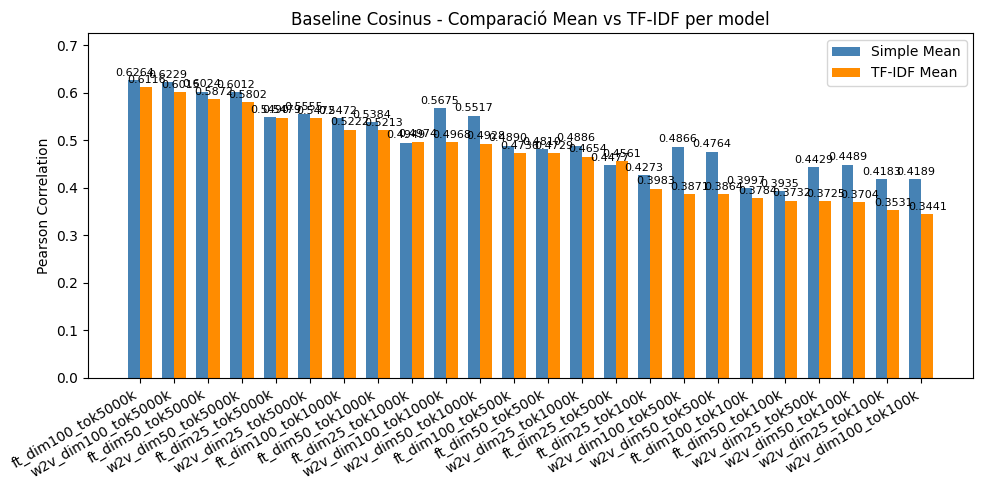

In [ ]:
# --- Gràfic: Bar plot comparació mean vs tfidf per model ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_baseline))
width = 0.35

bars1 = ax.bar(x - width/2, df_baseline["mean"], width, label="Simple Mean", color="steelblue")
bars2 = ax.bar(x + width/2, df_baseline["tfidf"], width, label="TF-IDF Mean", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(df_baseline["name"], rotation=30, ha="right")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Baseline Cosinus - Comparació Mean vs TF-IDF per model")
ax.legend()
ax.set_ylim(0, max(df_baseline[["mean","tfidf"]].max()) + 0.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


En aquest gràfic podem veure un petit resum dels resultats obtinguts amb els nostres models estàtics.

El primer que observem és que els models que utilitzen la **mitjana simple (mean)** en lloc de TF-IDF obtenen resultats de manera consistent una mica millors, tot i que aquesta diferència es redueix a mesura que el model millora. Això pot deure’s al fet que la mitjana simple tracta totes les paraules de manera uniforme, evitant donar massa pes a termes rars o poc representatius que el TF-IDF pot sobreponderar en alguns casos, especialment en frases curtes.

També es pot veure com la **mida del corpus (nombre de tokens)** té un impacte important en el rendiment del model, ja que els models amb corpus més grans són els que obtenen millors resultats. Això és esperable, ja que un corpus més gran proporciona embeddings més rics i robustos, amb millor cobertura del vocabulari i representacions més fiables de les paraules.

D’altra banda, la **dimensionalitat dels embeddings** no mostra una tendència tan clara, tot i que els millors resultats sí que es donen en models amb dimensionalitat més alta. Això passa perquè augmentar la dimensionalitat pot millorar la capacitat expressiva del model, però també pot introduir soroll o redundància, de manera que el benefici no sempre és lineal.

Finalment, no s’observa una diferència significativa entre **Word2Vec** i **FastText**, tot i que FastText sembla tenir un rendiment lleugerament superior en general. Això es pot explicar perquè FastText incorpora informació a nivell de subparaules (n-grams), cosa que li permet representar millor paraules rares o fora de vocabulari, però en aquest cas concret la diferència no és molt gran perquè el dataset i els embeddings utilitzats no penalitzen excessivament aquests casos.

El millor valor de correlació de Pearson obtingut és d’aproximadament **0.62**, un resultat que probablement millorarà a mesura que avancem en la pràctica.

---
## Part B — Model Seqüencial Siamès (BiLSTM + Atenció)

En aquesta segona part implementem un model seqüencial de tipus **siamès**, dissenyat per capturar millor la informació contextual de les frases que els models estàtics.

La idea principal és representar cada frase com una seqüència de paraules i processar-la amb una arquitectura neural més expressiva, en lloc de fer una simple agregació d’*embeddings*.

**Arquitectura del model**: Embedding → BiLSTM → Mecanisme d’atenció → MLP de regressió → similitud

**Input del model**: dues seqüències d’índexs de paraules

**Embeddings**: vectors preentrenats, que poden ser entrenables o congelats durant l’entrenament

### 7. Tokenització i vocabulari

En aquesta cel·la construïm el vocabulari a partir de totes les frases del dataset STS, utilitzant tant el conjunt d’entrenament com el de validació i test per assegurar una cobertura completa.

Definim també dos tokens especials:
- `<PAD>` per al padding de les seqüències
- `<UNK>` per representar paraules desconegudes

Un cop construït el vocabulari, creem la funció `encode`, que transforma una frase en una seqüència d’índexs. Aquesta funció limita la longitud de la seqüència a un màxim (`max_len`), aplica truncament si cal i afegeix padding quan la frase és més curta. 

A més, genera una màscara que indica quins elements són tokens reals i quins corresponen a padding, informació que serà útil en el model seqüencial per ignorar valors no vàlids durant el processament.

In [ ]:
# Construïm el vocabulari a partir de les frases del dataset STS
# Tokens especials: <PAD>=0, <UNK>=1
all_words = set()
for df in [train_df, val_df, test_df]:
    for col in ["sentence1", "sentence2"]:
        for sent in df[col]:
            all_words.update(tokenize(sent))

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w in sorted(all_words):
    word2idx[w] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f"Vocabulari STS: {VOCAB_SIZE:,} paraules")


def encode(text: str, max_len: int = 50) -> tuple[list[int], list[bool]]:
    """
    Converteix una frase a seqüència d'índexs amb padding.

    Cada token es transforma al seu índex dins del vocabulari.
    Si el token no existeix, s'utilitza <UNK>.

    També retorna una màscara que indica quins tokens són reals
    i quins corresponen a padding.

    Args:
        text (str): Frase d'entrada.
        max_len (int, optional): Longitud màxima de la seqüència. Per defecte 50.

    Returns:
        tuple[list[int], list[bool]]:
            - Seqüència d'índexs.
            - Màscara de padding (True = token real, False = padding).
    """
    tokens = tokenize(text)[:max_len]
    ids = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    mask = [True] * len(ids)
    # Padding
    while len(ids) < max_len:
        ids.append(0); mask.append(False)
    return ids, mask

Vocabulari STS: 11,906 paraules


### 8. Matriu d'embeddings pre-entrenats

En aquesta cel·la construïm la **matriu d’embeddings** a partir dels models preentrenats, alineada amb el vocabulari del dataset STS.

Per cada paraula del vocabulari intentem recuperar el seu vector corresponent del model d’*embeddings*. En cas que la paraula no estigui present (OOV), es manté la inicialització aleatòria. El token `<PAD>` es fixa explícitament a zero per assegurar que no aporti informació al model.

També es calcula la **cobertura del vocabulari**, que indica quin percentatge de paraules del dataset estan representades dins del model d’*embeddings*. Aquesta mètrica ens ajuda a entendre la qualitat i adequació del model respecte al domini del dataset.

Finalment, es generen les matrius d’embeddings per als dos models candidats (FastText i Word2Vec), que s’utilitzaran posteriorment en el model siamès, hem escollit aquests dos doncs són els dos que han obtingut millors resultats amb l'apartat anterior, a més també és interessant tenir un de **FastText** i un de **Word2Vec** per tal de comparar-los.

In [ ]:
def build_embedding_matrix(wv, word2idx: dict[str, int], dim: int) -> np.ndarray:
    """
    Construeix la matriu d'embeddings (VOCAB_SIZE x dim)
    a partir del model Gensim, alineada amb el vocabulari del dataset STS.
    Paraules OOV reben un vector aleatori petit.
    """
    matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), dim)).astype(np.float32)
    matrix[0] = 0  # <PAD> = zeros
    found = 0
    for word, idx in word2idx.items():
        if word in wv:
            matrix[idx] = wv[word]
            found += 1
    print(f"  Cobertura: {found}/{len(word2idx)} ({100*found/len(word2idx):.1f}%)")
    return matrix


# Triem els dos models candidats: FastText i Word2Vec, els dos millors
CANDIDATE_MODELS = {
    "ft":  "ft_dim100_tok5000k",
    "w2v": "w2v_dim100_tok5000k",
}

emb_matrices: dict[str, np.ndarray] = {}

for tag, model_name in CANDIDATE_MODELS.items():
    wv = wv_models[model_name]
    dim = wv.vector_size
    print(f"Model '{tag}': {model_name}  (dim={dim})")
    emb_matrices[tag] = build_embedding_matrix(wv, word2idx, dim)

Model 'ft': ft_dim100_tok5000k  (dim=100)
  Cobertura: 11906/11906 (100.0%)
Model 'w2v': w2v_dim100_tok5000k  (dim=100)
  Cobertura: 9595/11906 (80.6%)


### 9. Dataset PyTorch

En aquesta cel·la definim el dataset que utilitzarem per entrenar el model seqüencial siamès.

Fixem una longitud màxima de seqüència (`MAX_LEN = 50`) per assegurar que totes les frases tinguin la mateixa mida, aplicant truncament o padding segons sigui necessari.

La classe `STSDataset` s’encarrega de:
- Convertir cada frase en seqüències d’índexs mitjançant la funció `encode`
- Generar també la corresponent màscara per ignorar el padding
- Retornar les dues frases de cada parella juntament amb la seva puntuació de similitud

Finalment, es creen els `DataLoader` per a *train*, *validation* i *test*, que permeten iterar eficientment sobre el dataset en batches durant l’entrenament i l’avaluació del model.

In [11]:
MAX_LEN = 50

class STSDataset(Dataset):
    def __init__(self, df):
        self.data = df.reset_index(drop=True)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, i):
        row = self.data.iloc[i]
        ids1, mask1 = encode(row["sentence1"], MAX_LEN)
        ids2, mask2 = encode(row["sentence2"], MAX_LEN)
        return (
            torch.tensor(ids1),  torch.tensor(mask1),
            torch.tensor(ids2),  torch.tensor(mask2),
            torch.tensor(row["score"], dtype=torch.float),
        )

train_loader = DataLoader(STSDataset(train_df), batch_size=32, shuffle=True)
dev_loader   = DataLoader(STSDataset(val_df),   batch_size=64)
test_loader  = DataLoader(STSDataset(test_df),  batch_size=64)

### 10. Arquitectura del model seqüencial

Aquí definim l'arquitectura del model de la mateixa manera que està al PPT de l'enunciat.

El model segueix una arquitectura **siamesa amb BiLSTM i mecanisme d’atenció**, on cada frase es codifica de manera independent i després es comparen les seves representacions per estimar la similitud.

Primer, cada seqüència passa per una capa d’*embedding* (preentrenada), després per una **BiLSTM bidireccional**, i finalment per un **Attention Pooling**, que permet ponderar de manera adaptativa quines parts de la frase són més rellevants. Un cop obtingudes les representacions de les dues frases, es construeixen *features de comparació* (concatenació, diferència absoluta i producte element-wise) que s’introdueixen en un MLP de regressió per obtenir la predicció final de similitud.

Com a nota, s’han canviat les dimensions de `hidden_size` i `final_hidden_size` de 16 i 8 a 64 i 32 respectivament. S’ha fet així ja que hem pogut veure com aquestes noves dimensions donaven millors resultats que les anteriors.

In [12]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x, mask):
        scores = self.proj(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        alpha  = torch.softmax(scores, dim=-1)
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)


class SiameseBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_size=64, final_hidden_size=32,
                 trainable_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,
            padding_idx=0,
        )
        emb_dim = embedding_matrix.shape[1]
        self.encoder = nn.LSTM(emb_dim, hidden_size, batch_first=True,
                               bidirectional=True)
        self.pool = AttentionPooling(hidden_size * 2)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1 = self.encode(ids1, mask1)
        h2 = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1-h2), h1*h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

### 11. Entrenament del model seqüencial

En aquestes funcions implementem el procés d’entrenament i avaluació del model siamès.

La funció d’entrenament executa una època completa, actualitzant els pesos del model mitjançant *backpropagation* i retornant la pèrdua mitjana.

La funció d’avaluació posa el model en mode inferència i calcula la qualitat de les prediccions comparant-les amb les etiquetes reals mitjançant la correlació de **Pearson**.

In [ ]:
def train_epoch(model,loader,optimizer,criterion) -> float:
    """
    Entrena el model durant un epoch.

    Args:
        model: Model PyTorch a entrenar.
        loader: DataLoader d'entrenament.
        optimizer: Optimitzador.
        criterion: Funció de pèrdua.

    Returns:
        float: Pèrdua mitjana del epoch.
    """
    model.train()
    total_loss = 0
    for ids1, mask1, ids2, mask2, scores in loader:
        ids1, mask1, ids2, mask2, scores = (
            x.to(DEVICE) for x in (ids1, mask1, ids2, mask2, scores)
        )
        optimizer.zero_grad()
        preds = model(ids1, mask1, ids2, mask2)
        loss  = criterion(preds, scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model,loader) -> float:
    """
    Avalua el model calculant la correlació de Pearson entre prediccions i scores humans.

    Args:
        model: Model PyTorch.
        loader: DataLoader de validació o test.

    Returns:
        float: Correlació de Pearson arrodonida a 4 decimals.
    """
    model.eval()
    all_preds, all_scores = [], []
    with torch.no_grad():
        for ids1, mask1, ids2, mask2, scores in loader:
            ids1, mask1, ids2, mask2 = (
                x.to(DEVICE) for x in (ids1, mask1, ids2, mask2)
            )
            preds = model(ids1, mask1, ids2, mask2).cpu().numpy()
            all_preds.extend(preds)
            all_scores.extend(scores.numpy())
    r, _ = pearsonr(all_scores, all_preds)
    return round(r, 4)

En aquesta cel·la realitzem l’entrenament complet del model seqüencial siamès per a totes les combinacions de configuració possibles: embeddings de FastText i Word2Vec, tant en mode *frozen* com *trainable*.

Per a cada configuració, entrenem el model durant un nombre màxim d’èpoques, aplicant **early stopping** en funció del rendiment al conjunt de validació. En cada època es calcula la pèrdua d’entrenament i la correlació de Pearson al *dev set*, i es guarda el millor model segons aquest criteri.

Un cop finalitzat l’entrenament, es selecciona el millor model global en funció del rendiment al conjunt de test i es mostra un resum comparatiu de tots els experiments.

Finalment, es visualitza la corba d’entrenament del millor model, mostrant l’evolució de la *loss* i del Pearson al llarg de les èpoques, així com l’època òptima trobada.


── BiLSTM [FT]  embeddings frozen ──
  Epoch  2  loss=1.1598  dev_pearson=0.2641  (best_dev=0.2641, no_improve=0)
  Epoch  4  loss=1.1061  dev_pearson=0.3711  (best_dev=0.3711, no_improve=0)
  Epoch  6  loss=0.9918  dev_pearson=0.4218  (best_dev=0.4218, no_improve=0)
  Epoch  8  loss=0.8345  dev_pearson=0.5050  (best_dev=0.5050, no_improve=0)
  Epoch 10  loss=0.7097  dev_pearson=0.4664  (best_dev=0.5465, no_improve=1)
  Epoch 12  loss=0.6009  dev_pearson=0.6065  (best_dev=0.6065, no_improve=0)
  Epoch 14  loss=0.4686  dev_pearson=0.5811  (best_dev=0.6065, no_improve=2)
  Epoch 16  loss=0.4152  dev_pearson=0.6606  (best_dev=0.6606, no_improve=0)
  → Millor test Pearson: 0.6769

── BiLSTM [FT]  embeddings trainable ──
  Epoch  2  loss=1.1368  dev_pearson=0.3403  (best_dev=0.3403, no_improve=0)
  Epoch  4  loss=0.9817  dev_pearson=0.4241  (best_dev=0.4241, no_improve=0)
  Epoch  6  loss=0.4980  dev_pearson=0.3282  (best_dev=0.4241, no_improve=2)
  Epoch  8  loss=0.2395  dev_pearson=0.310

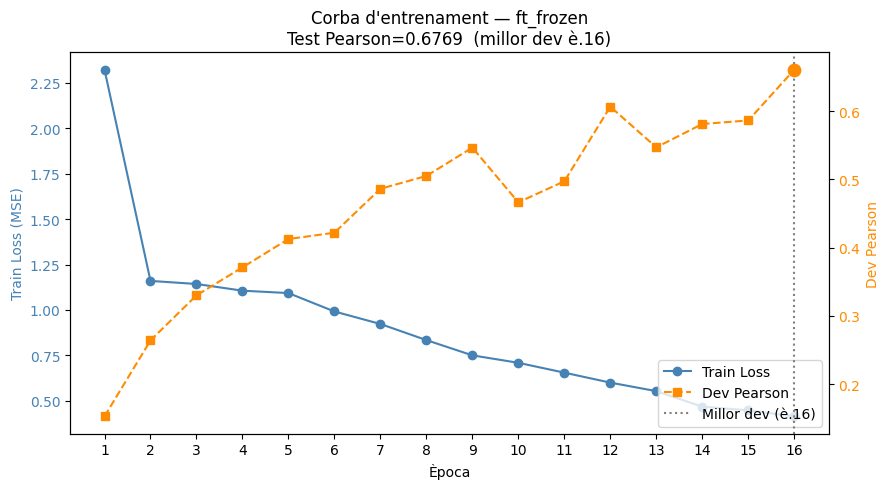

In [14]:
# ── Paràmetres d'entrenament ─────────────────────────────────────────────────
EPOCHS_SEQ = 16      # màxim d'èpoques
PATIENCE   = 4       # early stopping: epochs sense millora al dev

# ── Bucle principal: FT i W2V × frozen i trainable ──────────────────────────
seq_results  = {}   # {run_key: best_test_pearson}
all_histories = {}  # {run_key: {"epochs", "loss", "dev_pearson", "best_epoch"}}

for emb_tag, emb_matrix in emb_matrices.items():
    for trainable in [False, True]:
        label   = "trainable" if trainable else "frozen"
        run_key = f"{emb_tag}_{label}"
        print(f"\n── BiLSTM [{emb_tag.upper()}]  embeddings {label} ──")

        model     = SiameseBiLSTMAttention(
            emb_matrix, trainable_embeddings=trainable
        ).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.MSELoss()

        best_dev, best_test, best_epoch = -1, -1, -1
        no_improve = 0
        history = {"epochs": [], "loss": [], "dev_pearson": []}

        for epoch in range(1, EPOCHS_SEQ + 1):
            loss  = train_epoch(model, train_loader, optimizer, criterion)
            dev_r = evaluate(model, dev_loader)

            history["epochs"].append(epoch)
            history["loss"].append(loss)
            history["dev_pearson"].append(dev_r)

            if dev_r > best_dev:
                best_dev   = dev_r
                best_test  = evaluate(model, test_loader)
                best_epoch = epoch
                no_improve = 0
            else:
                no_improve += 1

            if epoch % 2 == 0:
                print(f"  Epoch {epoch:2d}  loss={loss:.4f}  "
                      f"dev_pearson={dev_r:.4f}  "
                      f"(best_dev={best_dev:.4f}, no_improve={no_improve})")

            if no_improve >= PATIENCE:
                print(f"  Early stopping a l'època {epoch}.")
                break

        history["best_epoch"] = best_epoch
        all_histories[run_key] = history
        seq_results[run_key]   = best_test
        print(f"  → Millor test Pearson: {best_test:.4f}")

# ── Triar el millor model ────────────────────────────────────────────────────
best_run = max(seq_results, key=seq_results.get)
print("\n" + "="*55)
print("Resum resultats model seqüencial:")
for k, v in seq_results.items():
    marca = " ◄ MILLOR" if k == best_run else ""
    print(f"  {k:<25}  Pearson={v:.4f}{marca}")
print("="*55)

# ── Gràfic corba d'entrenament del millor model ──────────────────────────────
h          = all_histories[best_run]
best_epoch = h["best_epoch"]

fig, ax1 = plt.subplots(figsize=(9, 5))

color_loss = "steelblue"
color_dev  = "darkorange"

ax1.set_xlabel("Època")
ax1.set_ylabel("Train Loss (MSE)", color=color_loss)
ax1.plot(h["epochs"], h["loss"],
         color=color_loss, marker="o", label="Train Loss")
ax1.tick_params(axis="y", labelcolor=color_loss)

ax2 = ax1.twinx()
ax2.set_ylabel("Dev Pearson", color=color_dev)
ax2.plot(h["epochs"], h["dev_pearson"],
         color=color_dev, marker="s", linestyle="--", label="Dev Pearson")
ax2.tick_params(axis="y", labelcolor=color_dev)

ax2.axvline(x=best_epoch, color="gray", linestyle=":", linewidth=1.5,
            label=f"Millor dev (è.{best_epoch})")
ax2.scatter([best_epoch], [h["dev_pearson"][best_epoch - 1]],
            color=color_dev, zorder=5, s=80)

ax1.set_title(f"Corba d'entrenament — {best_run}\n"
              f"Test Pearson={seq_results[best_run]:.4f}  "
              f"(millor dev è.{best_epoch})")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

ax1.set_xticks(h["epochs"])
plt.tight_layout()
plt.show()

Respecte als resultats d’aquests models, observem un parell de tendències clares.

Com ja havíem intuït, la correlació de Pearson obtinguda és superior a la dels models de l’apartat anterior, tot i que en l’apartat de conclusions en farem una anàlisi més detallada.

També veiem com els models que utilitzen la matriu d’*embeddings* de FastText obtenen millors resultats que els que fan servir Word2Vec. Això pot deure’s al fet que anteriorment també ja havíem observat un millor rendiment de FastText en els models estàtics, probablement gràcies a la seva capacitat de representar millor paraules rares mitjançant subparaules.

D’altra banda, els models en mode **frozen** són consistentment millors que els **trainable**. Això es pot explicar perquè el dataset STS és relativament petit i, en el cas de *trainable embeddings*, el model pot patir overfitting fàcilment. De fet, si no apliquéssim *early stopping*, el model trainable probablement continuaria ajustant-se fins a sobreajustar-se fortament. En canvi, el model frozen és més estable i aprofita millor les representacions preentrenades, fet que es tradueix en millors resultats.

Finalment, observem que, tot i que la *loss* disminueixi de manera consistent durant l’entrenament, això no sempre implica una millora en la correlació de Pearson. Això indica que el model pot estar millorant l’ajust numèric de les etiquetes, però no necessàriament la qualitat de la representació semàntica.

---
## Part C — Model BERT Siamès (BETO)

En aquesta tercera part implementem un model siamès basat en **BETO**, un model de tipus BERT entrenat específicament per a castellà. L’objectiu és millorar la capacitat del sistema per capturar relacions semàntiques complexes entre frases, aprofitant representacions contextuals en lloc d’*embeddings* estàtics o seqüencials.

**Arquitectura**: BETO → *Mean Pooling* → MLP de regressió → predicció de similitud

**Model base**: `dccuchile/bert-base-spanish-wwm-cased`

### 12. Tokenització BERT i Dataset

En aquesta cel·la preparem el *pipeline* de dades per al model BERT siamès.

Utilitzem el model **`dccuchile/bert-base-spanish-wwm-cased`**, conegut com a **BETO**, que és una adaptació de BERT entrenada específicament per a castellà. Aquest model ha estat preentrenat sobre grans corpus en espanyol, utilitzant la tècnica *Whole Word Masking (WWM)*, que millora la qualitat de les representacions en llenguatge natural.

S’utilitza aquest model en lloc d’un BERT multilingüe genèric perquè està **optimitzat per a la llengua espanyola**, captura millor matisos semàntics i morfològics del castellà i tendeix a oferir millors resultats en tasques NLP en espanyol com STS

A partir d’aquest model, carreguem el *tokenizer* associat i definim el dataset `STSDatasetBERT`, que converteix cada frase en tensors d’entrada compatibles amb BERT (`input_ids` i `attention_mask`).

Cada parella de frases es processa de manera independent i es retorna juntament amb la seva puntuació de similitud.

Finalment, es creen els `DataLoader` per a entrenament, validació i test, adaptats a BERT amb *batch sizes* més petits a causa del seu cost computacional.

In [15]:
BERT_MODEL = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer_bert = AutoTokenizer.from_pretrained(BERT_MODEL)

class STSDatasetBERT(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.data      = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        row = self.data.iloc[i]
        def enc(text):
            return self.tokenizer(text, max_length=self.max_len, padding="max_length",
                                  truncation=True, return_tensors="pt")
        e1 = enc(row["sentence1"])
        e2 = enc(row["sentence2"])
        return (
            e1["input_ids"].squeeze(),    e1["attention_mask"].squeeze(),
            e2["input_ids"].squeeze(),    e2["attention_mask"].squeeze(),
            torch.tensor(row["score"], dtype=torch.float),
        )

train_bert = DataLoader(STSDatasetBERT(train_df, tokenizer_bert), batch_size=16, shuffle=True)
dev_bert   = DataLoader(STSDatasetBERT(val_df,   tokenizer_bert), batch_size=32)
test_bert  = DataLoader(STSDatasetBERT(test_df,  tokenizer_bert), batch_size=32)

### 13. Arquitectura BERT Siamès

Definim el model de la mateixa manera que està a les *PPTs* de l’enunciat, seguint una arquitectura **siamesa basada en BETO** amb *mean pooling* sobre les representacions contextuals.

El model utilitza un encoder BERT preentrenat per obtenir representacions contextuals de cada frase, que després es combinen mitjançant diferents operacions (concatenació, diferència absoluta i producte element-wise) abans de passar per una capa de regressió.

Com a modificació respecte a l’arquitectura original, augmentem el *dropout* de **0.2 a 0.3** amb l’objectiu de reduir el sobreajust (*overfitting*) i millorar la generalització del model, intentant obtenir així el millor rendiment possible en el conjunt de test, per tant modifiquem lleugerament la classe **BETOSiameseRegressor** i també aprofitem per canviar la mida de la capa final.

In [ ]:
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name=BERT_MODEL, final_hidden_size=64, dropout=0.3):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        self.pool       = MeanPooling()
        hidden          = self.encoder.config.hidden_size
        self.regressor  = nn.Sequential(
            nn.Linear(hidden * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1    = self.encode(ids1, mask1)
        h2    = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1-h2), h1*h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

### 14. Entrenament del model BERT

En aquesta cel·la implementem una cerca d’hiperparàmetres per al model BERT siamès amb l’objectiu de trobar la configuració que maximitza el rendiment en el conjunt de validació.

Definim un espai de cerca simple (*grid search*) sobre dos hiperparàmetres principals:
- **Learning rate (lr)**: controla la velocitat d’aprenentatge del model
- **Weight decay**: regularització per evitar sobreajust

A cada configuració entrenem el model durant un nombre fix d’èpoques (`EPOCHS_BERT = 8`), utilitzant també un esquema de **warmup lineal** que ajuda a estabilitzar l’entrenament al principi.

Durant l’entrenament es calcula la pèrdua a cada època i, a continuació s’avalua el model en el conjunt de validació, aleshores es guarda el millor model segons el *dev Pearson*, finalment, es registra també el rendiment en test per a la millor època

A més, es fa servir **gradient clipping** per evitar gradients explosius, i es guarda el millor model de cada configuració.

Finalment, es mostren tots els resultats ordenats per rendiment en validació, incloent el temps d’entrenament de cada configuració, i es selecciona la millor combinació d’hiperparàmetres segons el conjunt de validació.

Com a nota, aquesta part en específic es va fer en **Google Colab** per tal de poder disposar de GPU per fer l'entrament, per tant també s'ha de guardar el model i carregar-lo posteriorment al Notebook en local.

In [ ]:
import itertools, time

SAVE_DIR = "/content/" 

# Cerca d'hiperparàmetres
EPOCHS_BERT   = 8
WARMUP_RATIO  = 0.1   # fracció d'steps per fer warmup 

# Grid: lr × dropout  (2×2 = 4 combinacions)
SEARCH_GRID = {
    "lr":      [2e-5, 5e-5],
    "weight_decay": [0.01, 0.05],
}

#Funció definida per fer el train per epoch afegint l'scheduler
def train_epoch_bert(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    for ids1, mask1, ids2, mask2, scores in loader:
        ids1, mask1, ids2, mask2, scores = (x.to(DEVICE) for x in
                                             (ids1, mask1, ids2, mask2, scores))
        optimizer.zero_grad()
        preds = model(ids1, mask1, ids2, mask2)
        loss  = criterion(preds, scores)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


search_results = []

configs = list(itertools.product(SEARCH_GRID["lr"], SEARCH_GRID["weight_decay"]))
print(f"Total configuracions: {len(configs)}  (~{len(configs)*EPOCHS_BERT} min)")
print("="*65)

for lr, weight_decay in configs:
    cfg_name = f"lr={lr:.0e}_weight_decay={weight_decay}"
    print(f"\n── Config: {cfg_name} ──")
    t0 = time.time()

    model_bert = BETOSiameseRegressor(final_hidden_size=64, dropout=0.3).to(DEVICE)

    optimizer_bert = torch.optim.AdamW(
        model_bert.parameters(), lr=lr, weight_decay=weight_decay
    )
    criterion_bert = nn.MSELoss()

    total_steps   = len(train_bert) * EPOCHS_BERT
    warmup_steps  = int(total_steps * WARMUP_RATIO)
    scheduler_bert = get_linear_schedule_with_warmup(
        optimizer_bert,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    print(f"  Steps totals={total_steps}  warmup={warmup_steps}")

    best_dev, best_test = -1, -1
    for epoch in range(1, EPOCHS_BERT + 1):
        loss  = train_epoch_bert(model_bert, train_bert,
                                 optimizer_bert, scheduler_bert, criterion_bert)
        dev_r = evaluate(model_bert, dev_bert)
        if dev_r > best_dev:
            best_dev  = dev_r
            best_test = evaluate(model_bert, test_bert)
            torch.save(model_bert.state_dict(),
                       SAVE_DIR + f"beto_{cfg_name}_best.pt")
            print(f"  ✓ Epoch {epoch}  loss={loss:.4f}  dev={dev_r:.4f}  [guardat]")
        else:
            print(f"    Epoch {epoch}  loss={loss:.4f}  dev={dev_r:.4f}")

    elapsed = (time.time() - t0) / 60
    search_results.append({
        "config": cfg_name, "lr": lr, "weight_decay": weight_decay,
        "best_dev": best_dev, "best_test": best_test, "min": round(elapsed, 1),
    })
    print(f"  → best dev={best_dev:.4f}  test={best_test:.4f}  ({elapsed:.1f} min)")

# Taula de resultats
print("\n" + "="*65)
print(f"{'Config':<30} {'Dev':>8} {'Test':>8} {'Temps':>7}")
print("="*65)
df_search = pd.DataFrame(search_results).sort_values("best_dev", ascending=False)
for _, row in df_search.iterrows():
    print(f"{row['config']:<30} {row['best_dev']:>8.4f} {row['best_test']:>8.4f} {row['min']:>6.1f}m")

best_row = df_search.iloc[0]
best_test_bert = best_row["best_test"]
print(f"\n★ Millor config: {best_row['config']}  →  Test Pearson = {best_test_bert:.4f}")


Total configuracions: 4  (~32 min)

── Config: lr=2e-05_weight_decay=0.01 ──


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

  Steps totals=664  warmup=66
  ✓ Epoch 1  loss=3.4319  dev=0.3270  [guardat]
  ✓ Epoch 2  loss=0.9310  dev=0.5202  [guardat]
  ✓ Epoch 3  loss=0.5643  dev=0.6131  [guardat]
  ✓ Epoch 4  loss=0.3379  dev=0.6836  [guardat]
  ✓ Epoch 5  loss=0.2539  dev=0.7119  [guardat]
  ✓ Epoch 6  loss=0.1972  dev=0.7302  [guardat]
    Epoch 7  loss=0.1745  dev=0.7176
    Epoch 8  loss=0.1574  dev=0.6965
  → best dev=0.7302  test=0.6708  (9.5 min)

── Config: lr=2e-05_weight_decay=0.05 ──


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

  Steps totals=664  warmup=66
  ✓ Epoch 1  loss=2.0443  dev=0.3181  [guardat]
  ✓ Epoch 2  loss=1.0275  dev=0.3722  [guardat]
  ✓ Epoch 3  loss=0.6728  dev=0.6228  [guardat]
    Epoch 4  loss=0.4330  dev=0.5620
  ✓ Epoch 5  loss=0.2756  dev=0.6873  [guardat]
    Epoch 6  loss=0.2156  dev=0.6816
  ✓ Epoch 7  loss=0.1921  dev=0.7198  [guardat]
    Epoch 8  loss=0.1623  dev=0.7100
  → best dev=0.7198  test=0.6368  (9.3 min)

── Config: lr=5e-05_weight_decay=0.05 ──


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

  Steps totals=664  warmup=66
  ✓ Epoch 1  loss=2.5256  dev=0.3080  [guardat]
  ✓ Epoch 2  loss=0.7539  dev=0.7409  [guardat]
  ✓ Epoch 3  loss=0.3865  dev=0.7613  [guardat]
    Epoch 4  loss=0.2926  dev=0.7365
  ✓ Epoch 5  loss=0.2083  dev=0.7758  [guardat]
    Epoch 6  loss=0.1839  dev=0.7552
    Epoch 7  loss=0.1523  dev=0.7674
    Epoch 8  loss=0.1431  dev=0.7667
  → best dev=0.7758  test=0.7417  (9.2 min)

Config                              Dev     Test   Temps
lr=5e-05_weight_decay=0.05       0.7758   0.7417    9.2m
lr=2e-05_weight_decay=0.01       0.7302   0.6708    9.5m
lr=5e-05_weight_decay=0.01       0.7198   0.6368    9.3m
lr=2e-05_weight_decay=0.05       0.6724   0.6457    9.1m

★ Millor config: lr=5e-05_weight_decay=0.05  →  Test Pearson = 0.7417


Un cop finalitzada la fase d’entrenament dels models BERT, podem observar clarament la influència dels hiperparàmetres en el rendiment del model.

En aquest cas, la millor configuració correspon a un **learning rate de 5e-5** i un **weight decay de 0.05**, fet que indica que el model es beneficia d’un aprenentatge relativament més ràpid combinat amb una regularització elevada. Això suggereix que, tot i que el model necessita actualitzacions prou significatives per adaptar-se al problema, també requereix un control fort per evitar el sobreajust.

Observant l’evolució de l’entrenament, veiem com la correlació de Pearson millora ràpidament durant les primeres èpoques, passant de valors baixos a més de 0.75 en només unes poques iteracions. Tot i que la *loss* continua disminuint de manera progressiva, la correlació es stabilitza i fins i tot oscil·la lleugerament, indicant que el model arriba ràpidament a una bona solució i després només fa ajustos fins.

Comparant amb la resta de configuracions, es veu clarament que valors més baixos de *weight decay* condueixen a pitjors resultats, probablement a causa d’un major sobreajust. D’altra banda, un *learning rate* massa baix (2e-5) sembla limitar la capacitat del model per convergir cap a una solució òptima dins del nombre d’èpoques fixat.

Finalment, aquest model és el que obté els millors resultats globals, amb una correlació de Pearson en test de **0.7417**, i serà el que compararem amb la resta de models en l’apartat de conclusions.

A continuació es mostra el codi necessari per recuperar el model BERT prèviament guardat al Drive. Un cop carregat, serà necessari tornar a avaluar-lo sobre el conjunt de *test* per obtenir de nou les mètriques de rendiment.

In [ ]:
bert_model = BETOSiameseRegressor(final_hidden_size=64, dropout=0.3)
bert_model.load_state_dict(torch.load("bert.pt", map_location="cpu"))
bert_model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BETOSiameseRegressor(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, eleme

In [36]:
best_test_bert = evaluate(bert_model, test_bert)
print(f"Test Pearson: {best_test_bert:.4f}")

Test Pearson: 0.7417


---
### 15. Resum final de totes les aproximacions

Aproximació                               Pearson
Baseline mean (ft_dim100_tok5000k)         0.6264
Baseline TF-IDF (ft_dim100_tok5000k)       0.6116
BiLSTM w2v_frozen                          0.6082
BiLSTM w2v_trainable                       0.3813
BiLSTM ft_frozen                           0.6769 ◄ MILLOR BiLSTM
BiLSTM ft_trainable                        0.4716
BETO Siamès                                0.7417 ◄ MILLOR GLOBAL


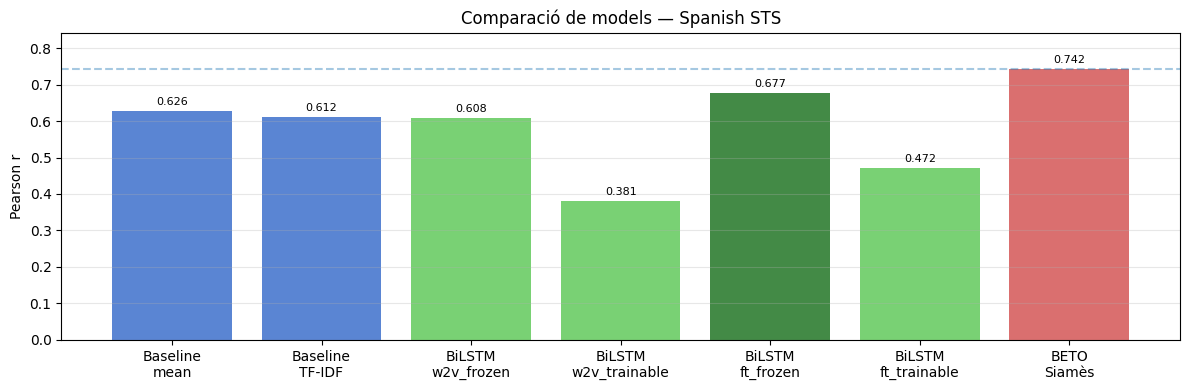

In [ ]:
# Millor baseline
best_bl = df_baseline.iloc[0]

# Millor BiLSTM (ja calculat abans)
best_seq_pearson = seq_results[best_run]

# ── PRINT TAULA ───────────────────────────────────────────────
print("="*60)
print(f"{'Aproximació':<40} {'Pearson':>8}")
print("="*60)

print(f"{'Baseline mean (' + best_bl['name'] + ')':<40} {best_bl['mean']:>8.4f}")
print(f"{'Baseline TF-IDF (' + best_bl['name'] + ')':<40} {best_bl['tfidf']:>8.4f}")

for run_key, pearson in seq_results.items():
    marca = " ◄ MILLOR BiLSTM" if run_key == best_run else ""
    print(f"{'BiLSTM ' + run_key:<40} {pearson:>8.4f}{marca}")

print(f"{'BETO Siamès':<40} {best_test_bert:>8.4f} ◄ MILLOR GLOBAL")
print("="*60)


# ── GRÀFIC ────────────────────────────────────────────────────
labels = (
    ["Baseline\nmean", "Baseline\nTF-IDF"]
    + [f"BiLSTM\n{k}" for k in seq_results.keys()]
    + ["BETO\nSiamès"]
)

values = (
    [best_bl["mean"], best_bl["tfidf"]]
    + [seq_results[k] for k in seq_results.keys()]
    + [best_test_bert]
)

# Colors coherents amb els teus experiments
colors = (
    ["#4878cf", "#4878cf"]  # baseline
    + ["#6acc65" if k != best_run else "#2e7d32" for k in seq_results.keys()]  # BiLSTM
    + ["#d65f5f"]  # BETO
)

fig, ax = plt.subplots(figsize=(12, 4))

bars = ax.bar(labels, values, color=colors, alpha=0.9)

# Etiquetes numèriques
ax.bar_label(
    bars,
    labels=[f"{v:.3f}" for v in values],
    padding=3,
    fontsize=8
)

# Línia millor model global
ax.axhline(best_test_bert, linestyle="--", alpha=0.4)

ax.set_ylabel("Pearson r")
ax.set_title("Comparació de models — Spanish STS")

ax.set_ylim(0, max(values) + 0.1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("grafic_extrinseca.png", dpi=120)
plt.show()

En aquesta primera gràfica veiem una comparativa global de tots els models, que ens servirà per identificar el millor model de cada mètode i poder-los comparar entre si.

Observem que el **Baseline Mean** és lleugerament superior al **Baseline TF-IDF**, i per tant seleccionem aquesta configuració com a millor baseline. Pel que fa al model **BiLSTM**, el millor rendiment s’obté amb la variant basada en **FastText**, que és la que escollim com a representativa d’aquest enfocament.

Finalment, es pot veure clarament com el model **BETO Siamès** és el que obté els millors resultats globals. A la següent cel·la entrarem en una comparativa més detallada per analitzar aquestes diferències amb més profunditat.

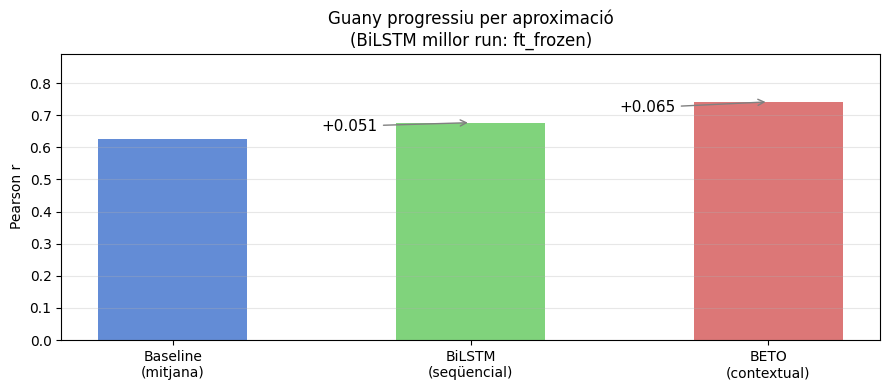

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))

etapes = ["Baseline\n(mitjana)", "BiLSTM\n(seqüencial)", "BETO\n(contextual)"]
valors = [best_bl["mean"], max(seq_results.values()), best_test_bert]
colors = ["#4878cf", "#6acc65", "#d65f5f"]

bars = ax.bar(etapes, valors, color=colors, alpha=0.85, width=0.5)

# Fletxes de guany
for i in range(len(valors) - 1):
    guany = valors[i+1] - valors[i]
    signe = "+" if guany >= 0 else ""
    ax.annotate(f"{signe}{guany:.3f}",
                xy=(i+1, valors[i+1]),
                xytext=(i+0.5, (valors[i] + valors[i+1]) / 2),
                fontsize=11, color="black",
                arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_ylabel("Pearson r")
ax.set_title(f"Guany progressiu per aproximació\n"
             f"(BiLSTM millor run: {best_run})")
ax.set_ylim(0, max(valors) + 0.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("grafic_guany_etapes.png", dpi=120, bbox_inches="tight")
plt.show()

## 16. Conclusions

Els resultats obtinguts mostren una millora progressiva clara a mesura que augmenta la complexitat dels models: **Baseline < BiLSTM < BETO**. Aquesta tendència es pot explicar principalment per la capacitat de cada model per capturar la informació semàntica de les frases.

En el cas dels models *baseline*, aquests es basen en agregacions simples d’*embeddings*, com la mitjana o la ponderació amb TF-IDF. Aquest enfocament és molt limitat, ja que es perd completament l’ordre de les paraules i no es té en compte el context en què apareixen. Com a resultat, les representacions de frase són bastant simples i no capturen adequadament la semàntica global.

El model **BiLSTM**, en canvi, introdueix una millora significativa perquè té en compte l’estructura seqüencial del llenguatge. Gràcies a la seva naturalesa bidireccional, és capaç de capturar dependències tant cap endavant com cap enrere dins de la frase. A més, amb el mecanisme d’atenció, el model pot focalitzar-se en les paraules més rellevants per a la tasca. Tot això permet construir representacions molt més riques i adaptades al problema de similitud semàntica, cosa que explica que superi clarament el baseline.

Finalment, el model **BETO** (basat en BERT) obté els millors resultats perquè treballa amb representacions contextuals profundes. A diferència dels models anteriors, BETO ha estat preentrenat sobre grans quantitats de text, de manera que ja incorpora coneixement lingüístic molt ric abans de ser ajustat a la tasca específica. Això li permet capturar relacions semàntiques complexes i matisos del llenguatge que els altres models no poden representar. A més, cada paraula es representa de manera diferent segons el seu context, cosa que resulta especialment útil en una tasca com STS. Per tot això, el model BETO és capaç de superar tant el baseline com el model seqüencial, tot i que la diferència tampoc es tant elevada.